POWER SYSTEM FOR CONVERTER-DRIVEN STABILITY STUDY

In [1]:
import villas.dataprocessing.readtools as rt
import villas.dataprocessing.plottools as pt
from villas.dataprocessing.timeseries import TimeSeries as ts
import math
import dpsimpy

Infeed Power System equivalent

In [3]:
# Nodes
gnd = dpsimpy.emt.SimNode.gnd
n1 = dpsimpy.emt.SimNode('n1')
n2 = dpsimpy.emt.SimNode('n2')

# Components
vs = dpsimpy.emt.ph3.VoltageSource('vs')
vs.set_parameters(dpsimpy.Math.single_phase_variable_to_three_phase(complex(100000, 0)), 50)
r1 = dpsimpy.emt.ph3.Resistor('r_1')
r1.set_parameters(dpsimpy.Math.single_phase_parameter_to_three_phase(0.005))
l1 = dpsimpy.emt.ph3.Inductor('l_1')
l1.set_parameters(dpsimpy.Math.single_phase_parameter_to_three_phase(0.01))

# Connections
vs.connect([gnd, n1])
r1.connect([n1, n2])
l1.connect([n2, gnd])

Pi equivalent circuits for transmission line

Converter

Load

Converter

In [4]:
# DPsim EMT simulation
name = 'Compare_DP_EMT_RMS_ConverterDrivenStability_Powersystem'

# Define system topology
system = dpsimpy.SystemTopology(50, [gnd, n1, n2], [vs, r1, l1])
# Logging
logger = dpsimpy.Logger(name)
logger.log_attribute('n2.v', 'v', n2)
logger.log_attribute('n1.v', 'v', n1)

sim = dpsimpy.Simulation(name)
sim.set_system(system)
sim.set_domain(dpsimpy.Domain.EMT)
sim.set_time_step(0.0001)
sim.set_final_time(0.1)
sim.add_logger(logger)

sim.run()

[17:40:28.013952 MnaSolverFactory info] creating KLUAdapter solver implementation


In [8]:
work_dir = 'logs/'
log_name = 'Compare_DP_EMT_RMS_ConverterDrivenStability_Powersystem'
print(work_dir + log_name + '.csv')

ts_dpsim_emt = rt.read_timeseries_dpsim(work_dir + log_name + '.csv')

logs/Compare_DP_EMT_RMS_ConverterDrivenStability_Powersystem.csv
column number: 2
results length: 1001
real column names: ['n1.v', 'n2.v']
complex column names: []


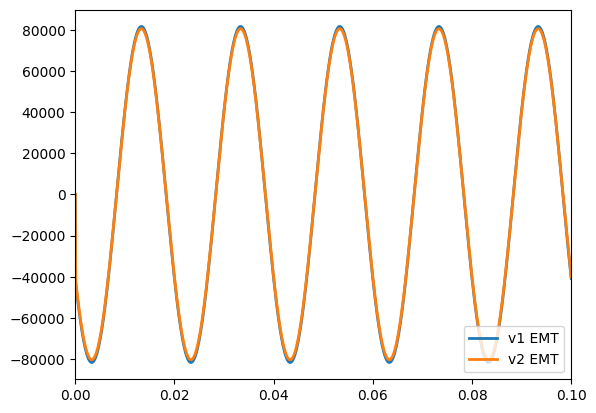

In [10]:
ts_dpsim_emt['n1.v'].label = 'v1 EMT'
ts_dpsim_emt['n2.v'].label = 'v2 EMT'
pt.plot_timeseries(1, ts_dpsim_emt['n1.v'])
pt.plot_timeseries(1, ts_dpsim_emt['n2.v'])